In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import kagglehub
# CHANGE THIS LINE for each notebook
from tensorflow.keras.applications import ResNet50

LOADING THE DATASET

In [ ]:
path = kagglehub.dataset_download("omkarmanohardalvi/lungs-disease-dataset-4-types")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lungs-disease-dataset-4-types' dataset.
Path to dataset files: /kaggle/input/lungs-disease-dataset-4-types


IMAGE PREPROCESSING

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)
dataset_path = dataset_path = "/kaggle/input/lungs-disease-dataset-4-types/Lung Disease Dataset"
print(os.listdir(dataset_path))

['val', 'test', 'train']


LOADING TRAIN TEST VAL DATA

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path + "/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 6054 images belonging to 5 classes.


In [ ]:
val_generator = test_datagen.flow_from_directory(
    dataset_path + "/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 2016 images belonging to 5 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    dataset_path + "/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2025 images belonging to 5 classes.


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.2569 - loss: 1.6098 - val_accuracy: 0.3214 - val_loss: 1.5409
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 140s 739ms/step - accuracy: 0.3175 - loss: 1.5297 - val_accuracy: 0.3874 - val_loss: 1.4780
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 141s 738ms/step - accuracy: 0.3558 - loss: 1.4800 - val_accuracy: 0.4444 - val_loss: 1.4099
Epoch 4/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 140s 737ms/step - accuracy: 0.3759 - loss: 1.4395 - val_accuracy: 0.4673 - val_loss: 1.3897
Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 142s 749ms/step - accuracy: 0.3730 - loss: 1.4355 - val_accuracy: 0.4514 - val_loss: 1.3387
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 142s 746ms/step - accuracy: 0.3839 - loss: 1.4161 - val_accuracy: 0.4613 - val_loss: 1.3290
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 140s 737ms/step - accuracy: 0.3930 - loss: 1.3965 - val_accuracy: 0.4375 - val_loss: 1.2956
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 141s 745ms/step - accuracy: 0.4118 - lo

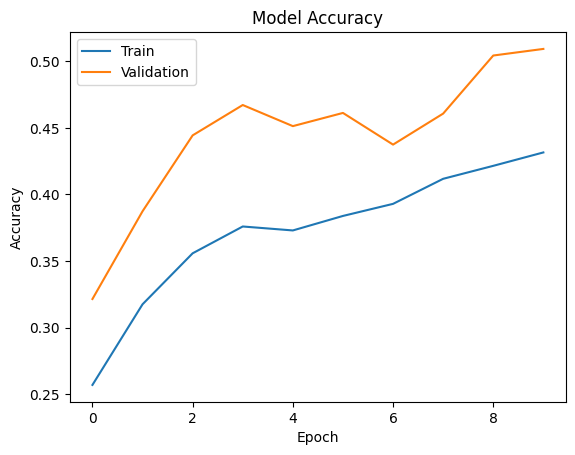

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

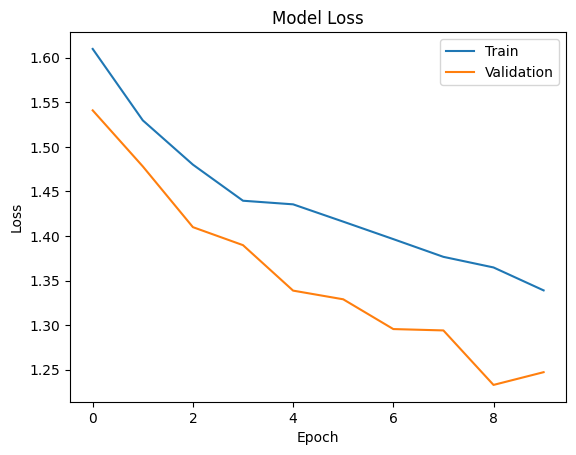

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Get predictions
predictions = model.predict(test_generator)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = test_generator.classes

64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 682ms/step


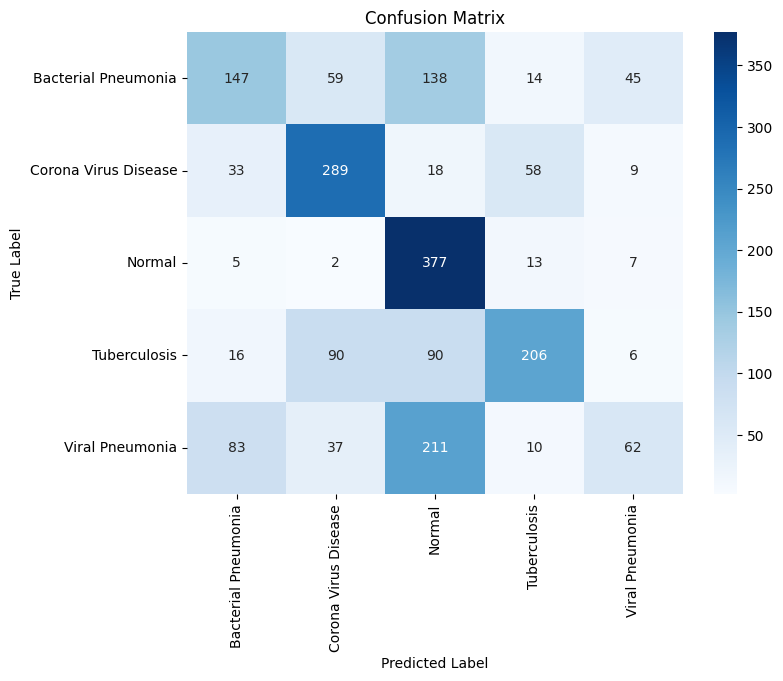

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_true, y_pred, average='weighted')
print("Precision:", precision)
recall = recall_score(y_true, y_pred, average='weighted')
print("Recall:", recall)
f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

Accuracy: 0.5338271604938272
Precision: 0.5485070758099209
Recall: 0.5338271604938272
F1 Score: 0.501557719697018
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.52      0.36      0.43       403
Corona Virus Disease       0.61      0.71      0.65       407
              Normal       0.45      0.93      0.61       404
        Tuberculosis       0.68      0.50      0.58       408
     Viral Pneumonia       0.48      0.15      0.23       403

            accuracy                           0.53      2025
           macro avg       0.55      0.53      0.50      2025
        weighted avg       0.55      0.53      0.50      2025

